<a href="https://colab.research.google.com/github/lukianenkoromanfb61mp-ui/IAD/blob/main/PR2_Lukianenko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Перед написанням программи в коллаб потрібно встановити wordcloud.

In [2]:
!pip install wordcloud -q

1. Імпорти.

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import time, urllib.request, zipfile, io, re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, silhouette_score, adjusted_rand_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

2. Дані.

In [4]:
RS = 42
sns.set_style("whitegrid")

# --- Dry Bean ---
url = "https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip"
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    df = pd.read_excel(zf.open([n for n in zf.namelist() if n.endswith('.xlsx')][0]))

le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
X, y = df.drop('Class', axis=1), df['Class']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                           random_state=RS, stratify=y)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)
print("Dry Bean:", X_tr_s.shape, X_te_s.shape)

Dry Bean: (10208, 16) (3403, 16)


3. Baseline vs PCA.

In [5]:
# без PCA
t0 = time.time()
acc0 = accuracy_score(y_te, SVC(random_state=RS).fit(X_tr_s, y_tr).predict(X_te_s))
t0 = time.time() - t0

# з PCA (залишаємо 95% варіації)
pca = PCA(n_components=0.95, random_state=RS)
X_tr_p = pca.fit_transform(X_tr_s)
X_te_p = pca.transform(X_te_s)

t1 = time.time()
acc1 = accuracy_score(y_te, SVC(random_state=RS).fit(X_tr_p, y_tr).predict(X_te_p))
t1 = time.time() - t1

print(f"Без PCA:  16 ознак  accuracy={acc0:.4f}  час={t0:.2f}с")
print(f"З PCA:    {X_tr_p.shape[1]} ознак  accuracy={acc1:.4f}  час={t1:.2f}с")

Без PCA:  16 ознак  accuracy=0.9254  час=4.63с
З PCA:    4 ознак  accuracy=0.9001  час=3.64с


4. t-SNE.

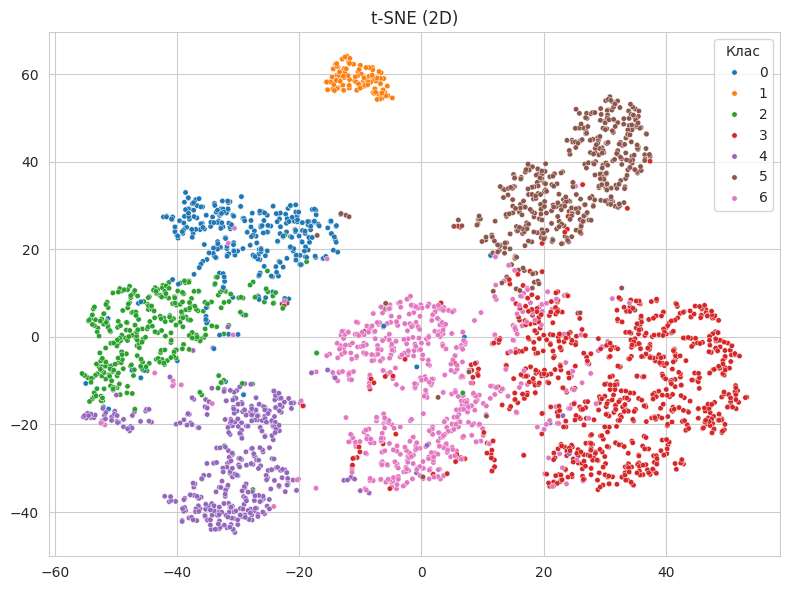

In [6]:
idx = np.random.RandomState(RS).choice(len(X_tr_s), 3000, replace=False)
X2 = TSNE(n_components=2, perplexity=30, random_state=RS,
          init='pca', learning_rate='auto').fit_transform(X_tr_s[idx])

plt.figure(figsize=(8,6))
sns.scatterplot(x=X2[:,0], y=X2[:,1], hue=y_tr.values[idx], palette='tab10', s=15)
plt.title("t-SNE (2D)"); plt.legend(title='Клас', bbox_to_anchor=(1,1))
plt.tight_layout(); plt.show()

5. Elbow + Silhouette + візуалізація.

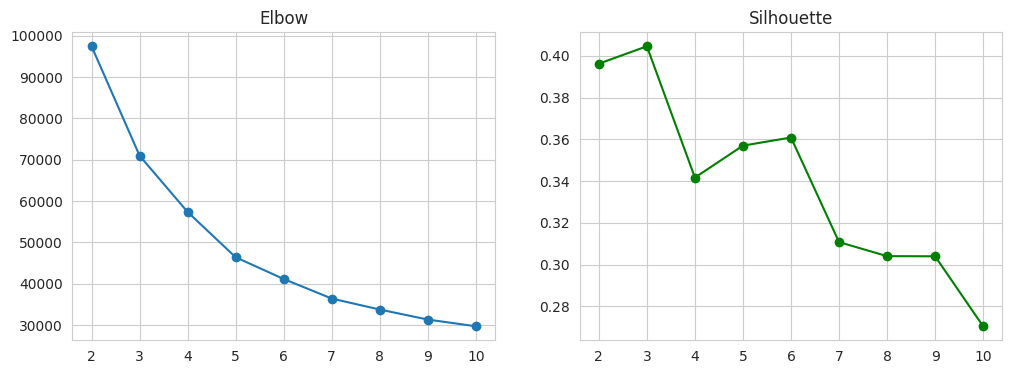

k=3, ARI=0.298


In [7]:
inertia, sil = [], []
for k in range(2, 11):
    lbl = KMeans(n_clusters=k, random_state=RS, n_init=10).fit_predict(X_tr_s)
    inertia.append(KMeans(n_clusters=k, random_state=RS, n_init=10).fit(X_tr_s).inertia_)
    sil.append(silhouette_score(X_tr_s, lbl))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(range(2,11), inertia, marker='o'); ax[0].set_title("Elbow")
ax[1].plot(range(2,11), sil, marker='o', color='g'); ax[1].set_title("Silhouette")
plt.show()

best_k = int(np.argmax(sil)) + 2
km = KMeans(n_clusters=best_k, random_state=RS, n_init=10)
labels = km.fit_predict(X_tr_s)
print(f"k={best_k}, ARI={adjusted_rand_score(y_tr, labels):.3f}")

6. Візуалізація кластерів vs справжніх класів.

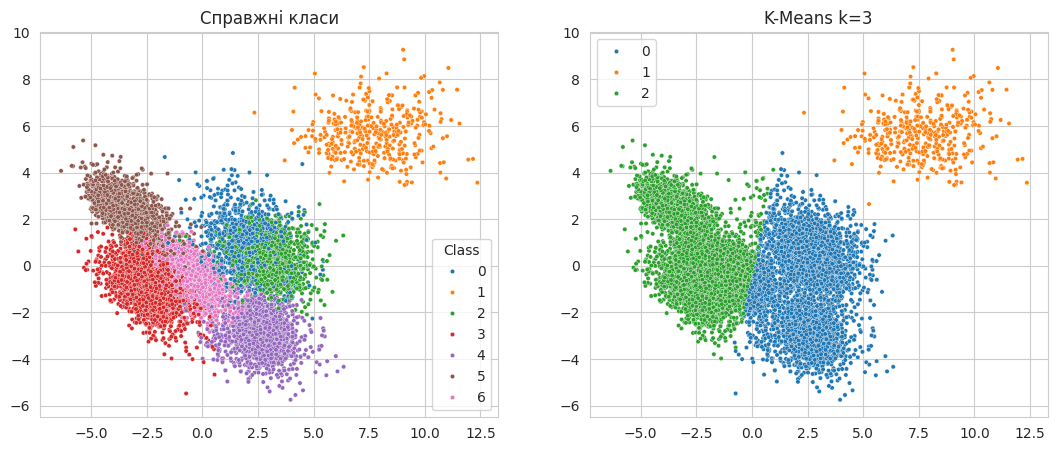

In [8]:
X2p = PCA(n_components=2, random_state=RS).fit_transform(X_tr_s)
fig, ax = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(x=X2p[:,0], y=X2p[:,1], hue=y_tr, palette='tab10', s=10, ax=ax[0])
ax[0].set_title("Справжні класи")
sns.scatterplot(x=X2p[:,0], y=X2p[:,1], hue=labels, palette='tab10', s=10, ax=ax[1])
ax[1].set_title(f"K-Means k={best_k}")
plt.show()

7. Завантаження та препроцесинг.

In [9]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
sms = pd.read_csv(url, sep='\t', header=None, names=['label','message'])

def clean(t):
    return re.sub(r'\s+', ' ', re.sub(r'[^a-z\s]', ' ', t.lower())).strip()

sms['clean'] = sms['message'].apply(clean)
print(sms['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


8. WordCloud.

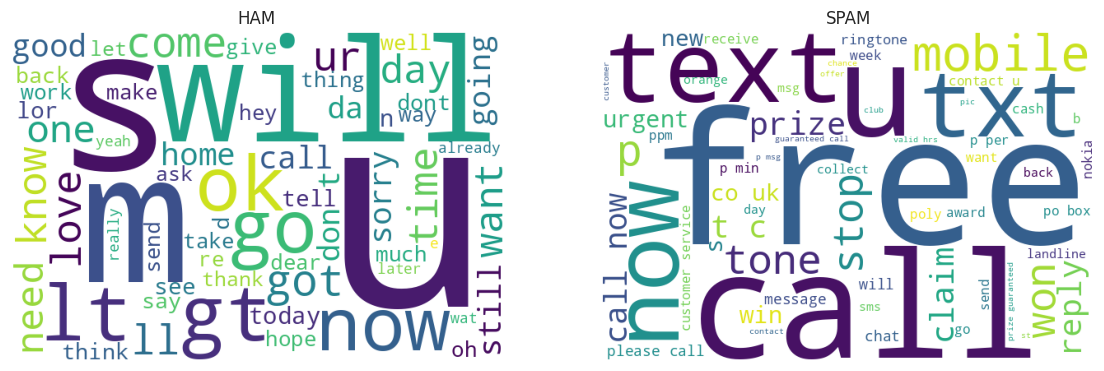

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
for i, cls in enumerate(['ham','spam']):
    text = ' '.join(sms.loc[sms['label']==cls, 'clean'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=60).generate(text)
    ax[i].imshow(wc); ax[i].axis('off'); ax[i].set_title(cls.upper())
plt.show()

9. TF-IDF + класифікація.

In [11]:
y_txt = (sms['label'] == 'spam').astype(int).values
Xtr, Xte, ytr, yte = train_test_split(sms['clean'], y_txt,
                                       test_size=0.25, random_state=RS, stratify=y_txt)

tf = TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=2)
Vtr = tf.fit_transform(Xtr); Vte = tf.transform(Xte)

clf = MultinomialNB().fit(Vtr, ytr)
pred = clf.predict(Vte)
print("Accuracy:", round(accuracy_score(yte, pred), 4))
print(classification_report(yte, pred, target_names=['ham','spam']))
print(confusion_matrix(yte, pred))

Accuracy: 0.9691
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98      1206
        spam       1.00      0.77      0.87       187

    accuracy                           0.97      1393
   macro avg       0.98      0.89      0.93      1393
weighted avg       0.97      0.97      0.97      1393

[[1206    0]
 [  43  144]]
